# network_v2: Baseline + Experiment Tracking + Optuna + Rich Analysis

This notebook keeps the **current baseline architecture** and improves experimentation/analysis:
- Optional Optuna hyperparameter search with SQLite storage
- Optional Optuna dashboard hook
- Save/load best params (`.json`) and best model weights (`.pt`)
- Save all generated plots to disk
- Model summary stats (params/layers/dimensions)
- Loss/accuracy curves, confusion matrices, weight analysis, and intermediate spike-stage visualizations


## How To Use

1. Run cells top-to-bottom once.
2. Set `RUN_OPTUNA=True` if you want fresh hyperparameter tuning.
3. If a checkpoint exists and `LOAD_CHECKPOINT_IF_AVAILABLE=True`, training is skipped.
4. All artifacts are saved under `artifacts_v2/`.


In [62]:
from pathlib import Path
import json
import random
import subprocess
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import optuna
import snntorch as snn


In [63]:
# ===== Experiment config =====
SEED = 7

EXPERIMENT_NAME = "network_v2_baseline"

RUN_OPTUNA = False
N_TRIALS = 12
TRIAL_EPOCHS = 15
FULL_EPOCHS = 40

FORCE_RETRAIN = False
LOAD_CHECKPOINT_IF_AVAILABLE = True

OPTUNA_STUDY_NAME = "radar_snn_v2_study"

BASE_DIR = Path("artifacts_v2")
PLOT_DIR = BASE_DIR / "plots"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
PARAM_DIR = BASE_DIR / "params"
OPTUNA_DIR = BASE_DIR / "optuna"

for d in [BASE_DIR, PLOT_DIR, CHECKPOINT_DIR, PARAM_DIR, OPTUNA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

OPTUNA_DB_PATH = OPTUNA_DIR / f"{OPTUNA_STUDY_NAME}.sqlite3"
BEST_PARAMS_PATH = PARAM_DIR / f"{EXPERIMENT_NAME}_best_params.json"
CHECKPOINT_PATH = CHECKPOINT_DIR / f"{EXPERIMENT_NAME}_best.pt"

print("Artifacts root:", BASE_DIR.resolve())
print("Checkpoint path:", CHECKPOINT_PATH)
print("Best-params JSON:", BEST_PARAMS_PATH)
print("Optuna DB:", OPTUNA_DB_PATH)


Artifacts root: /Users/jackhenry/Library/CloudStorage/OneDrive-UniversityofCambridge/IIB Project work/Radar_SNN_3/artifacts_v2
Checkpoint path: artifacts_v2/checkpoints/network_v2_baseline_best.pt
Best-params JSON: artifacts_v2/params/network_v2_baseline_best_params.json
Optuna DB: artifacts_v2/optuna/radar_snn_v2_study.sqlite3


In [64]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def save_fig(name: str) -> Path:
    path = PLOT_DIR / name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved plot: {path}")
    return path


set_seed(SEED)


In [65]:
# Optional feature checks
HAS_SPIKEPLOT = True
HAS_OPTUNA_DASHBOARD = True
SPIKEPLOT_IMPORT_ERROR = None
DASHBOARD_IMPORT_ERROR = None

try:
    import snntorch.spikeplot as splt
except Exception as e:
    HAS_SPIKEPLOT = False
    SPIKEPLOT_IMPORT_ERROR = e

try:
    import optuna_dashboard  # noqa: F401
except Exception as e:
    HAS_OPTUNA_DASHBOARD = False
    DASHBOARD_IMPORT_ERROR = e

print("HAS_SPIKEPLOT:", HAS_SPIKEPLOT)
if not HAS_SPIKEPLOT:
    print("  spikeplot unavailable:", repr(SPIKEPLOT_IMPORT_ERROR))
    print("  install hint: pip install pandas")

print("HAS_OPTUNA_DASHBOARD:", HAS_OPTUNA_DASHBOARD)
if not HAS_OPTUNA_DASHBOARD:
    print("  dashboard unavailable:", repr(DASHBOARD_IMPORT_ERROR))
    print("  install hint: pip install optuna-dashboard")


HAS_SPIKEPLOT: True
HAS_OPTUNA_DASHBOARD: True


In [66]:
# Device setup
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using NVIDIA GPU (CUDA)")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")


Using Apple Silicon GPU (MPS)


In [67]:
# Baseline signal + dataset config
DT = 1e-4
T_STEPS = 768
TIME = np.arange(T_STEPS) * DT
SPEED_OF_SOUND = 343.0

DISTANCE_CLASSES_M = np.arange(0.5, 10.5, 0.5)
NUM_CLASSES = len(DISTANCE_CLASSES_M)

PULSE_CENTER_STEP = 35
PULSE_STD_STEPS = 6.0
ECHO_ATTENUATION = 0.55

SAMPLES_PER_CLASS = 40

DEFAULT_PARAMS = {
    "hidden_size": 96,
    "beta": 0.95,
    "lr": 1e-3,
    "batch_size": 64,
}

DELAY_STEPS = torch.unique(
    torch.cat((torch.arange(0, 257, 8), torch.arange(272, 673, 16)))
).long()

assert int(DELAY_STEPS.max().item()) < T_STEPS


In [68]:
def gaussian_pulse(t_steps, center_step, std_steps, amplitude=1.0):
    idx = np.arange(t_steps)
    return amplitude * np.exp(-0.5 * ((idx - center_step) / std_steps) ** 2)


def make_pulse_echo_signal(distance_m):
    pulse = gaussian_pulse(T_STEPS, PULSE_CENTER_STEP, PULSE_STD_STEPS)
    delay_seconds = 2.0 * distance_m / SPEED_OF_SOUND
    delay_steps = int(round(delay_seconds / DT))

    echo = np.zeros_like(pulse)
    if delay_steps < T_STEPS:
        echo[delay_steps:] = ECHO_ATTENUATION * pulse[: T_STEPS - delay_steps]

    signal = pulse + echo
    return signal.astype(np.float32), pulse.astype(np.float32), echo.astype(np.float32), delay_steps


def build_dataset(samples_per_class=SAMPLES_PER_CLASS, seed=SEED):
    rng = np.random.default_rng(seed)
    signals = []
    labels = []

    for class_idx, dist_m in enumerate(DISTANCE_CLASSES_M):
        base_signal, _, _, _ = make_pulse_echo_signal(float(dist_m))
        for _ in range(samples_per_class):
            signals.append(base_signal)
            labels.append(class_idx)

    X = np.stack(signals)
    y = np.array(labels, dtype=np.int64)

    perm = rng.permutation(len(X))
    X = X[perm]
    y = y[perm]

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    return X_train, y_train, X_test, y_test


def make_loaders(X_train, y_train, X_test, y_test, batch_size):
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_ds, test_ds, train_loader, test_loader


Saved plot: artifacts_v2/plots/signal_example.png


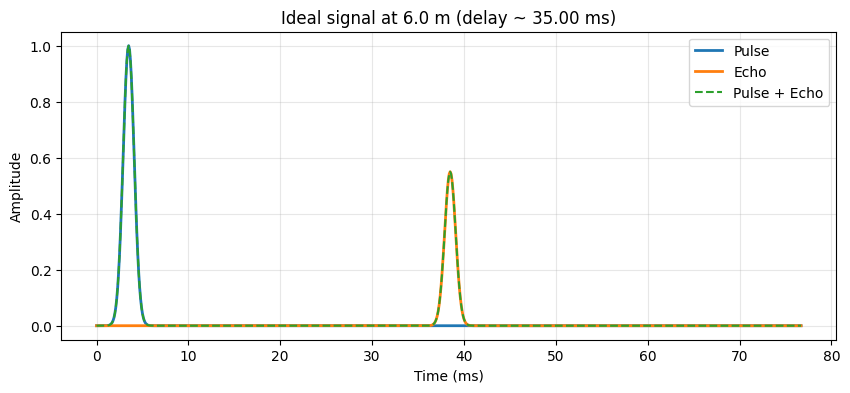

In [69]:
# Example signal plot
example_distance = 6.0
example_signal, example_pulse, example_echo, example_delay_steps = make_pulse_echo_signal(example_distance)

plt.figure(figsize=(10, 4))
plt.plot(TIME * 1e3, example_pulse, label="Pulse", linewidth=2)
plt.plot(TIME * 1e3, example_echo, label="Echo", linewidth=2)
plt.plot(TIME * 1e3, example_signal, label="Pulse + Echo", linestyle="--")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title(f"Ideal signal at {example_distance:.1f} m (delay ~ {example_delay_steps * DT * 1e3:.2f} ms)")
plt.grid(alpha=0.3)
plt.legend()
save_fig("signal_example.png")
plt.show()


In [70]:
class DelayBank(nn.Module):
    def __init__(self, delays):
        super().__init__()
        self.register_buffer("delays", delays.clone().long())

    def forward(self, x):
        # x: [T, B, 1]
        t_steps, batch_size, _ = x.shape
        n_delays = self.delays.numel()

        out = torch.zeros(t_steps, batch_size, n_delays, device=x.device, dtype=x.dtype)
        x_flat = x[:, :, 0]

        for i, d in enumerate(self.delays.tolist()):
            if d == 0:
                out[:, :, i] = x_flat
            elif d < t_steps:
                out[d:, :, i] = x_flat[: t_steps - d, :]

        return out


class EchoDistanceSNN(nn.Module):
    def __init__(self, delays, hidden_size, num_classes, beta=0.95):
        super().__init__()
        self.delay_bank = DelayBank(delays)
        self.fc1 = nn.Linear(len(delays), hidden_size)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_size, num_classes)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, x, return_intermediate=False):
        delayed = self.delay_bank(x)
        self.lif1.reset_mem()
        self.lif2.reset_mem()

        mem1 = None
        mem2 = None
        spk_hidden_rec = []
        spk_out_rec = []

        for t in range(delayed.shape[0]):
            cur1 = self.fc1(delayed[t])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk_hidden_rec.append(spk1)
            spk_out_rec.append(spk2)

        spk_hidden_rec = torch.stack(spk_hidden_rec, dim=0)
        spk_out_rec = torch.stack(spk_out_rec, dim=0)

        if return_intermediate:
            return spk_out_rec, {
                "delayed": delayed,
                "spk_hidden": spk_hidden_rec,
                "spk_out": spk_out_rec,
            }
        return spk_out_rec, spk_hidden_rec


In [71]:
def print_model_summary(model, params):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    num_linear_layers = sum(1 for m in model.modules() if isinstance(m, nn.Linear))
    num_lif_layers = sum(1 for m in model.modules() if isinstance(m, snn.Leaky))

    print("\n=== Model Summary ===")
    print(f"Input time steps: {T_STEPS}")
    print(f"Distance classes: {NUM_CLASSES}")
    print(f"Delay channels: {len(DELAY_STEPS)} (min={int(DELAY_STEPS.min().item())}, max={int(DELAY_STEPS.max().item())} steps)")
    print(f"Hidden dimension: {params['hidden_size']}")
    print(f"Linear layers: {num_linear_layers}")
    print(f"LIF layers: {num_lif_layers}")
    print(f"Total parameters: {total_params}")
    print(f"Trainable parameters: {trainable_params}")
    print(f"Training params: {params}")


In [72]:
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            x_time = x_batch.unsqueeze(-1).permute(1, 0, 2)

            spk_out, _ = model(x_time)
            spike_counts = spk_out.sum(dim=0)

            loss = criterion(spike_counts, y_batch)
            total_loss += loss.item() * y_batch.size(0)

            preds = spike_counts.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, test_loader, lr, epochs, device, verbose=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
    }

    best_state = None
    best_test_loss = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            x_time = x_batch.unsqueeze(-1).permute(1, 0, 2)

            optimizer.zero_grad()
            spk_out, _ = model(x_time)
            spike_counts = spk_out.sum(dim=0)

            loss = criterion(spike_counts, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * y_batch.size(0)
            preds = spike_counts.argmax(dim=1)
            running_correct += (preds == y_batch).sum().item()
            running_total += y_batch.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == epochs):
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc * 100:.1f}% | "
                f"test_loss={test_loss:.4f}, test_acc={test_acc * 100:.1f}%"
            )

    return history, best_state, best_test_loss


In [73]:
def save_best_params_json(params, path: Path, metadata=None):
    payload = {"params": params, "metadata": metadata or {}}
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    print(f"Saved best params JSON: {path}")


def load_best_params_json(path: Path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    return payload.get("params", None)


def save_checkpoint(model, history, params, path: Path):
    payload = {
        "model_state_dict": model.state_dict(),
        "history": history,
        "params": params,
        "distance_classes_m": DISTANCE_CLASSES_M.tolist(),
        "delay_steps": DELAY_STEPS.tolist(),
    }
    torch.save(payload, path)
    print(f"Saved checkpoint: {path}")


def load_checkpoint(model, path: Path, map_location=DEVICE):
    payload = torch.load(path, map_location=map_location)
    model.load_state_dict(payload["model_state_dict"])
    history = payload.get("history", None)
    params = payload.get("params", None)
    print(f"Loaded checkpoint: {path}")
    return history, params


In [74]:
# Build dataset once for reproducible studies/runs
X_train, y_train, X_test, y_test = build_dataset(samples_per_class=SAMPLES_PER_CLASS, seed=SEED)
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Classes (distance m): {DISTANCE_CLASSES_M.tolist()}")
print(f"Chance accuracy: {100.0 / NUM_CLASSES:.1f}%")


Train samples: 640, Test samples: 160
Classes (distance m): [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
Chance accuracy: 5.0%


In [ ]:
def objective(trial):
    set_seed(SEED + trial.number)

    params = {
        "hidden_size": trial.suggest_categorical("hidden_size", [64, 96, 128, 160]),
        "beta": trial.suggest_float("beta", 0.85, 0.99),
        "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
    }

    _, _, train_loader_t, test_loader_t = make_loaders(
        X_train, y_train, X_test, y_test, batch_size=params["batch_size"]
    )

    model_t = EchoDistanceSNN(
        delays=DELAY_STEPS,
        hidden_size=params["hidden_size"],
        num_classes=NUM_CLASSES,
        beta=params["beta"],
    ).to(DEVICE)

    history_t, _, best_test_loss = train_model(
        model_t,
        train_loader_t,
        test_loader_t,
        lr=params["lr"],
        epochs=TRIAL_EPOCHS,
        device=DEVICE,
        verbose=False,
    )

    max_train_acc = float(max(history_t["train_acc"]))
    max_test_acc = float(max(history_t["test_acc"]))
    trial.set_user_attr("max_train_acc", max_train_acc)
    trial.set_user_attr("max_test_acc", max_test_acc)

    # Early-stop criterion requested: stop as soon as a trial reaches 100% train + test accuracy.
    if max_train_acc >= 0.999 and max_test_acc >= 0.999:
        trial.set_user_attr("perfect_accuracy", True)
        trial.study.set_user_attr("perfect_params", params)
        trial.study.set_user_attr("perfect_trial_number", trial.number)
        trial.study.stop()
        # Use a value better than any non-perfect trial in this minimization study.
        return -1e-6

    return best_test_loss


if RUN_OPTUNA:
    storage = f"sqlite:///{OPTUNA_DB_PATH.resolve()}"
    study = optuna.create_study(
        study_name=OPTUNA_STUDY_NAME,
        storage=storage,
        direction="minimize",
        load_if_exists=True,
    )
    study.optimize(objective, n_trials=N_TRIALS)

    perfect_params = study.user_attrs.get("perfect_params", None)
    if perfect_params is not None:
        best_params = perfect_params
        print("Optuna stopped early on perfect train+test accuracy.")
        print("Perfect trial number:", study.user_attrs.get("perfect_trial_number"))
    else:
        best_params = study.best_params

    print("Optuna best value:", study.best_value)
    print("Selected params:", best_params)

    save_best_params_json(
        best_params,
        BEST_PARAMS_PATH,
        metadata={
            "study_name": OPTUNA_STUDY_NAME,
            "storage": storage,
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "used_perfect_early_stop": perfect_params is not None,
            "perfect_trial_number": study.user_attrs.get("perfect_trial_number", None),
        },
    )
else:
    loaded_params = load_best_params_json(BEST_PARAMS_PATH)
    best_params = loaded_params if loaded_params is not None else DEFAULT_PARAMS.copy()
    print("Using params:", best_params)


In [76]:
# Final model run: load checkpoint or train
set_seed(SEED)

_, test_ds, train_loader, test_loader = make_loaders(
    X_train, y_train, X_test, y_test, batch_size=best_params["batch_size"]
)

model = EchoDistanceSNN(
    delays=DELAY_STEPS,
    hidden_size=best_params["hidden_size"],
    num_classes=NUM_CLASSES,
    beta=best_params["beta"],
).to(DEVICE)

print_model_summary(model, best_params)

if LOAD_CHECKPOINT_IF_AVAILABLE and CHECKPOINT_PATH.exists() and not FORCE_RETRAIN:
    history, ckpt_params = load_checkpoint(model, CHECKPOINT_PATH, map_location=DEVICE)
    if ckpt_params is not None:
        print("Checkpoint params:", ckpt_params)
else:
    history, best_state, _ = train_model(
        model,
        train_loader,
        test_loader,
        lr=best_params["lr"],
        epochs=FULL_EPOCHS,
        device=DEVICE,
        verbose=True,
    )
    model.load_state_dict(best_state)
    save_checkpoint(model, history, best_params, CHECKPOINT_PATH)

    save_best_params_json(
        best_params,
        BEST_PARAMS_PATH,
        metadata={"source": "final_training", "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")},
    )



=== Model Summary ===
Input time steps: 768
Distance classes: 20
Delay channels: 59 (min=0, max=672 steps)
Hidden dimension: 96
Linear layers: 2
LIF layers: 2
Total parameters: 7700
Trainable parameters: 7700
Training params: {'hidden_size': 96, 'beta': 0.95, 'lr': 0.001, 'batch_size': 64}
Loaded checkpoint: artifacts_v2/checkpoints/network_v2_baseline_best.pt
Checkpoint params: {'hidden_size': 96, 'beta': 0.95, 'lr': 0.001, 'batch_size': 64}


Saved plot: artifacts_v2/plots/training_curves.png


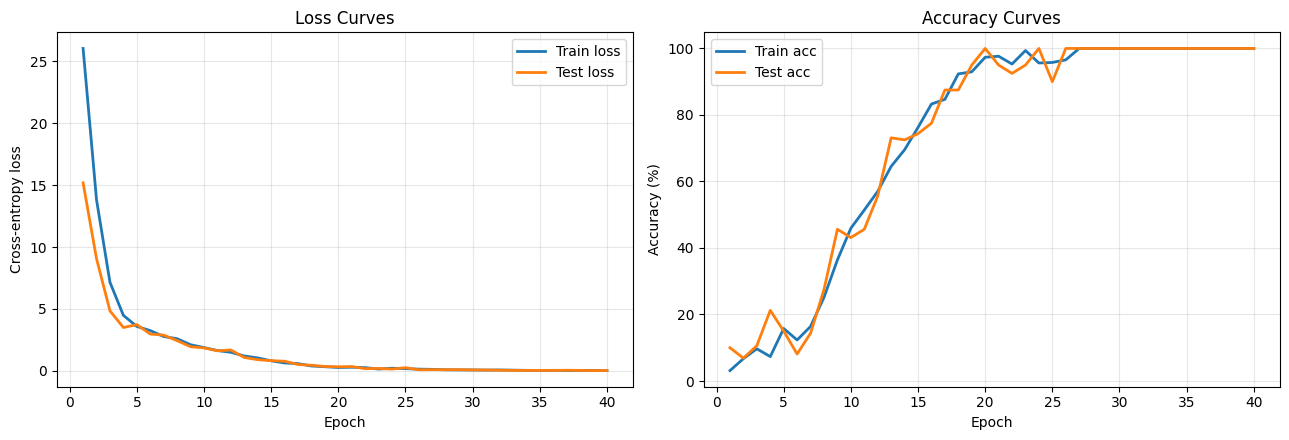

In [77]:
# Loss and accuracy curves
if history is not None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, history["train_loss"], label="Train loss", linewidth=2)
    axes[0].plot(epochs, history["test_loss"], label="Test loss", linewidth=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].set_title("Loss Curves")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, np.array(history["train_acc"]) * 100, label="Train acc", linewidth=2)
    axes[1].plot(epochs, np.array(history["test_acc"]) * 100, label="Test acc", linewidth=2)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Accuracy Curves")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    save_fig("training_curves.png")
    plt.show()
else:
    print("No history found; skipping curves.")


Saved plot: artifacts_v2/plots/confusion_matrix.png


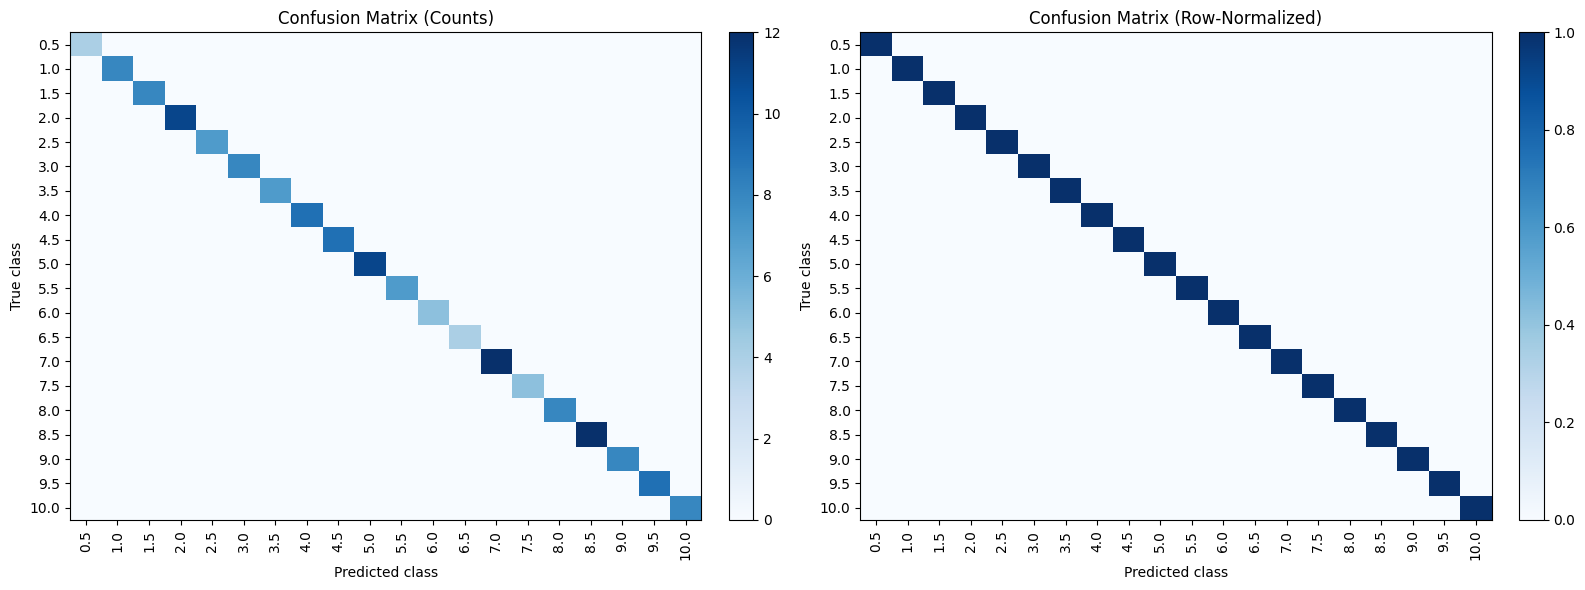

In [78]:
# Confusion matrix heatmaps
model.eval()
all_true = []
all_pred = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        x_time = x_batch.unsqueeze(-1).permute(1, 0, 2)
        spk_out, _ = model(x_time)
        spike_counts = spk_out.sum(dim=0)
        preds = spike_counts.argmax(dim=1)

        all_true.append(y_batch.cpu().numpy())
        all_pred.append(preds.cpu().numpy())

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
for t, p in zip(all_true, all_pred):
    cm[t, p] += 1

cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(cm, cmap="Blues", aspect="auto")
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("True class")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(cm_norm, cmap="Blues", vmin=0.0, vmax=1.0, aspect="auto")
axes[1].set_title("Confusion Matrix (Row-Normalized)")
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("True class")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

tick_idx = np.arange(NUM_CLASSES)
tick_labels = [f"{d:.1f}" for d in DISTANCE_CLASSES_M]
for ax in axes:
    ax.set_xticks(tick_idx)
    ax.set_yticks(tick_idx)
    ax.set_xticklabels(tick_labels, rotation=90)
    ax.set_yticklabels(tick_labels)

plt.tight_layout()
save_fig("confusion_matrix.png")
plt.show()


Saved plot: artifacts_v2/plots/weights_distribution_and_sorted.png


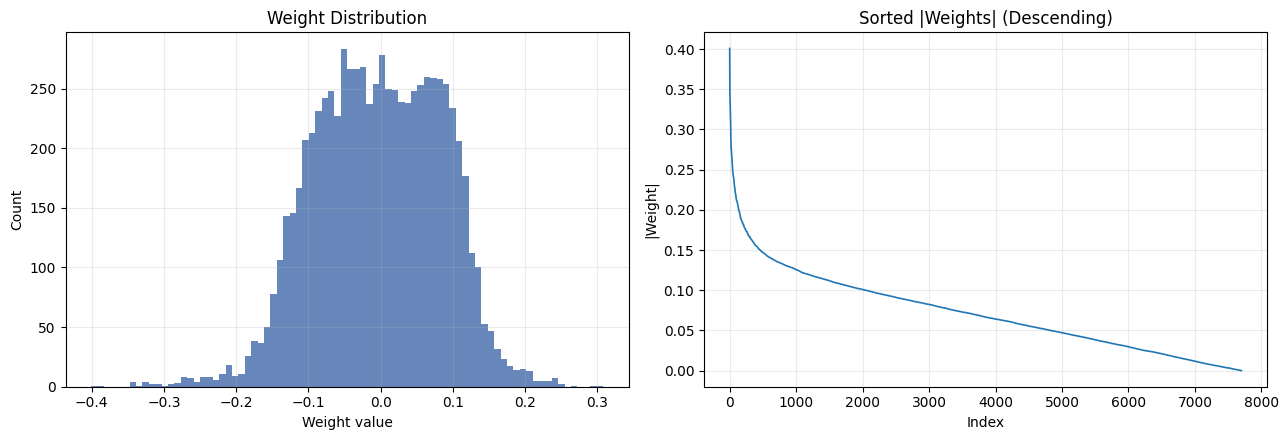

In [79]:
# Weight analysis: histogram + sorted magnitudes
all_weights = []
for p in model.parameters():
    if p.requires_grad:
        all_weights.append(p.detach().cpu().flatten().numpy())
all_weights = np.concatenate(all_weights)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(all_weights, bins=80, color="#4C72B0", alpha=0.85)
axes[0].set_title("Weight Distribution")
axes[0].set_xlabel("Weight value")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.25)

sorted_abs = np.sort(np.abs(all_weights))[::-1]
axes[1].plot(sorted_abs, linewidth=1.2)
axes[1].set_title("Sorted |Weights| (Descending)")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("|Weight|")
axes[1].grid(alpha=0.25)

plt.tight_layout()
save_fig("weights_distribution_and_sorted.png")
plt.show()


Saved plot: artifacts_v2/plots/intermediate_delay_channels.png


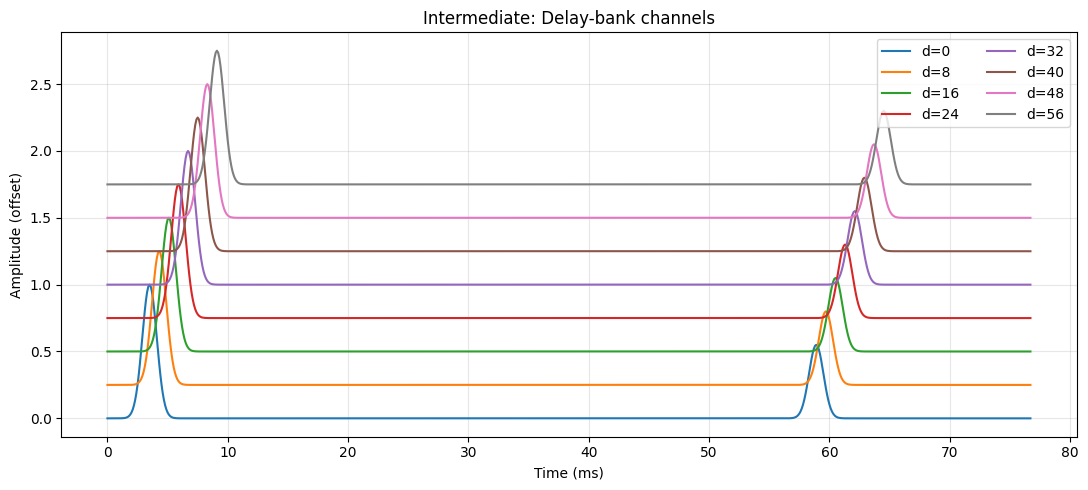

Saved plot: artifacts_v2/plots/intermediate_spikes.png


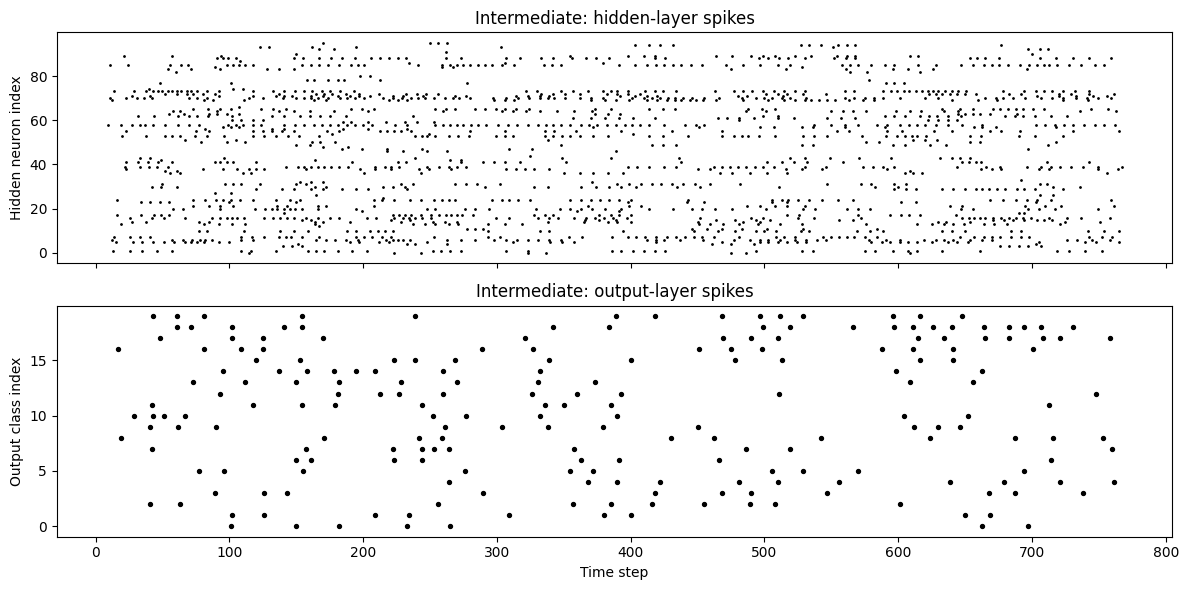

In [80]:
# Intermediate-stage activity plots (delay channels + spikes)
sample_signal, sample_label = test_ds[0]
sample_input = sample_signal.unsqueeze(0).unsqueeze(-1).permute(1, 0, 2).to(DEVICE)

model.eval()
with torch.no_grad():
    _, inter = model(sample_input, return_intermediate=True)

delayed_np = inter["delayed"][:, 0, :].cpu().numpy()
spk_hidden_np = inter["spk_hidden"][:, 0, :].cpu().numpy()
spk_out_np = inter["spk_out"][:, 0, :].cpu().numpy()

# Delay channels
n_show = min(8, delayed_np.shape[1])
plt.figure(figsize=(11, 5))
for i in range(n_show):
    plt.plot(TIME * 1e3, delayed_np[:, i] + i * 0.25, label=f"d={int(DELAY_STEPS[i].item())}")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (offset)")
plt.title("Intermediate: Delay-bank channels")
plt.grid(alpha=0.3)
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
save_fig("intermediate_delay_channels.png")
plt.show()

# Hidden spikes + output spikes
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

used_spikeplot = False
if HAS_SPIKEPLOT:
    try:
        splt.raster(torch.from_numpy(spk_hidden_np), ax=axes[0], s=1.0, c="black")
        splt.raster(torch.from_numpy(spk_out_np), ax=axes[1], s=8.0, c="black")
        used_spikeplot = True
    except Exception as e:
        print("spikeplot call failed; fallback to imshow. Error:", repr(e))

if not used_spikeplot:
    axes[0].imshow(spk_hidden_np.T, aspect="auto", cmap="Greys", origin="lower")
    axes[1].imshow(spk_out_np.T, aspect="auto", cmap="Greys", origin="lower")

axes[0].set_title("Intermediate: hidden-layer spikes")
axes[0].set_ylabel("Hidden neuron index")
axes[1].set_title("Intermediate: output-layer spikes")
axes[1].set_ylabel("Output class index")
axes[1].set_xlabel("Time step")

plt.tight_layout()
save_fig("intermediate_spikes.png")
plt.show()


In [81]:
# Optuna dashboard helper (optional)
storage_url = f"sqlite:///{OPTUNA_DB_PATH.resolve()}"
print("Optuna storage URL:", storage_url)

if HAS_OPTUNA_DASHBOARD:
    print("Dashboard launch command:")
    print(f"  optuna-dashboard {storage_url} --port 8080")
else:
    print("optuna-dashboard not installed. Install with:")
    print("  pip install optuna-dashboard")


def launch_optuna_dashboard(port=8080):
    if not HAS_OPTUNA_DASHBOARD:
        print("optuna-dashboard not installed; cannot launch from notebook.")
        return None

    cmd = [
        "optuna-dashboard",
        storage_url,
        "--port",
        str(port),
    ]
    print("Starting:", " ".join(cmd))
    return subprocess.Popen(cmd)


Optuna storage URL: sqlite:////Users/jackhenry/Library/CloudStorage/OneDrive-UniversityofCambridge/IIB Project work/Radar_SNN_3/artifacts_v2/optuna/radar_snn_v2_study.sqlite3
Dashboard launch command:
  optuna-dashboard sqlite:////Users/jackhenry/Library/CloudStorage/OneDrive-UniversityofCambridge/IIB Project work/Radar_SNN_3/artifacts_v2/optuna/radar_snn_v2_study.sqlite3 --port 8080
